In [ ]:
!pip install forestplot

In [ ]:
import pandas as pd
import numpy as np

# Gerando dados fictícios para 10 estudos sobre o efeito da penicilina no autismo
np.random.seed(42)  # Para reprodutibilidade

data = {
    'study': [f'Estudo {i+1}' for i in range(10)],
    'n': np.random.randint(50, 200, size=10),  # Tamanho da amostra
    'effect_size': np.random.uniform(-0.5, 0.5, size=10),  # Tamanho do efeito
    'ci_lower': np.random.uniform(-0.7, 0.1, size=10),  # Limite inferior do IC
    'ci_upper': np.random.uniform(0.1, 0.7, size=10),  # Limite superior do IC
    'p_val': np.random.uniform(0.001, 0.1, size=10),  # Valor p
    'group': ['A']*5 + ['B']*5  # Grupos de estudos
}

df = pd.DataFrame(data)

# Corrigindo para garantir que ci_lower < ci_upper
df['ci_lower'] = df.apply(lambda row: min(row['ci_lower'], row['ci_upper']), axis=1)
df['ci_upper'] = df.apply(lambda row: max(row['ci_lower'], row['ci_upper']), axis=1)

# Exibindo o DataFrame
df

,study,n,effect_size,ci_lower,ci_upper,p_val,group
0,Estudo 1,152,-0.166291,-0.694347,0.689939,0.023858,A
1,Estudo 2,142,-0.357133,-0.681550,0.380058,0.024862,A
2,Estudo 3,64,0.150888,-0.280180,0.615964,0.068643,A
3,Estudo 4,156,-0.443588,-0.380111,0.508185,0.061390,A
4,Estudo 5,121,0.221999,-0.662667,0.370300,0.083486,A
5,Estudo 6,70,0.438553,0.079004,0.107959,0.018163,B
6,Estudo 7,152,-0.499221,-0.513783,0.665321,0.039715,B
7,Estudo 8,171,0.492212,-0.627515,0.437973,0.019041,B
8,Estudo 9,124,0.117482,-0.205291,0.331250,0.075781,B
9,Estudo 10,137,0.111653,-0.394030,0.109580,0.043090,B


# DataFrame

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import forestplot as fp  # Certifique-se de que essa biblioteca esteja instalada

# Dados de exemplo
data = {
    'control': [100, 150, 120, 130, 110, 140, 160, 125, 135, 145],
    'r': [0.45, 0.65, 0.75, 0.55, 0.60, 0.70, 0.80, 0.68, 0.77, 0.59],
    'CI95%': ['(0.075, 0.95)', '(-0.55, 0.75)', '(0.65, 0.85)', '(0.45, 0.65)', '(0.50, 0.70)', '(0.60, 0.80)',
              '(0.70, 0.90)', '(0.58, 0.78)', '(0.67, 0.87)', '(0.49, 0.69)'],
    'p-val': [0.001, 0.05, 0.0198076, 0.08, 0.03, 0.02, 0.005, 0.07, 0.04, 0.06],
    'BF10': [10.5, 8.7, 9.2, 7.1, 8.0, 9.5, 10.0, 8.3, 9.0, 7.5],
    'Intervenction': [0.9, 0.8, 0.85, 0.75, 0.78, 0.83, 0.88, 0.80, 0.82, 0.79],
    'var': [0.01, 0.015, 0.012, 0.014, 0.013, 0.016, 0.011, 0.014, 0.013, 0.015],
    'll': [0.075, -0.55, 0.65, 0.45, 0.50, 0.60, 0.70, 0.58, 0.67, 0.49],
    'hl': [0.95, 0.75, 0.85, 0.65, 0.70, 0.80, 0.90, 0.78, 0.87, 0.69],
    'moerror': [0.05, 0.1, 0.07, 0.12, 0.09, 0.08, 0.06, 0.11, 0.10, 0.09],
    'group': ['sem MA', 'sem MA', 'com MA', 'sem MA', 'com MA', 'sem MA', 'com MA', 'com MA', 'sem MA', 'sem MA'],
    'label': ['Estudo 1', 'Estudo 2', 'Estudo 3', 'Estudo 4', 'Estudo 5', 'Estudo 6', 'Estudo 7',
              'Estudo 8', 'Estudo 9', 'Estudo 10']
}

# Criando o DataFrame
df = pd.DataFrame(data)
df

,control,r,CI95%,p-val,BF10,Intervenction,var,ll,hl,moerror,group,label
0,100,0.45,"(0.075, 0.95)",0.001000,10.5,0.90,0.010,0.075,0.95,0.05,sem MA,Estudo 1
1,150,0.65,"(-0.55, 0.75)",0.050000,8.7,0.80,0.015,-0.550,0.75,0.10,sem MA,Estudo 2
2,120,0.75,"(0.65, 0.85)",0.019808,9.2,0.85,0.012,0.650,0.85,0.07,com MA,Estudo 3
3,130,0.55,"(0.45, 0.65)",0.080000,7.1,0.75,0.014,0.450,0.65,0.12,sem MA,Estudo 4
4,110,0.60,"(0.50, 0.70)",0.030000,8.0,0.78,0.013,0.500,0.70,0.09,com MA,Estudo 5
5,140,0.70,"(0.60, 0.80)",0.020000,9.5,0.83,0.016,0.600,0.80,0.08,sem MA,Estudo 6
6,160,0.80,"(0.70, 0.90)",0.005000,10.0,0.88,0.011,0.700,0.90,0.06,com MA,Estudo 7
7,125,0.68,"(0.58, 0.78)",0.070000,8.3,0.80,0.014,0.580,0.78,0.11,com MA,Estudo 8
8,135,0.77,"(0.67, 0.87)",0.040000,9.0,0.82,0.013,0.670,0.87,0.10,sem MA,Estudo 9
9,145,0.59,"(0.49, 0.69)",0.060000,7.5,0.79,0.015,0.490,0.69,0.09,sem MA,Estudo 10


# Intervalo de confiança

In [ ]:
ci_list=df['CI95%'].tolist()
# Extrair os valores dos intervalos de confiança
ci_values = []
for ci in ci_list:
    # Removendo os parênteses e separando os valores
    min_val, max_val = ci.strip('()').split(', ')
    # Convertendo para float e adicionando na lista
    ci_values.append((float(min_val), float(max_val)))

# Encontrando o mínimo e o máximo valor
min_value = min(val[0] for val in ci_values)
max_value = max(val[1] for val in ci_values)

# Verificando se todos os valores de ll são menores que hl
if not all(df['ll'] < df['hl']):
    raise ValueError("Todos os valores de 'll' devem ser menores que 'hl'")

In [ ]:
# Formatando as colunas necessárias para a função forestplot
df['est_ci'] = df.apply(lambda row: f"{row['r']:.2f} ({row['ll']:.2f}, {row['hl']:.2f})", axis=1)
df['formatted_pval'] = df['p-val'].apply(lambda x: f"{x:.6f}")
df

,control,r,CI95%,p-val,BF10,Intervenction,var,ll,hl,moerror,group,label,est_ci,formatted_pval
0,100,0.45,"(0.075, 0.95)",0.001000,10.5,0.90,0.010,0.075,0.95,0.05,sem MA,Estudo 1,"0.45 (0.07, 0.95)",0.001000
1,150,0.65,"(-0.55, 0.75)",0.050000,8.7,0.80,0.015,-0.550,0.75,0.10,sem MA,Estudo 2,"0.65 (-0.55, 0.75)",0.050000
2,120,0.75,"(0.65, 0.85)",0.019808,9.2,0.85,0.012,0.650,0.85,0.07,com MA,Estudo 3,"0.75 (0.65, 0.85)",0.019808
3,130,0.55,"(0.45, 0.65)",0.080000,7.1,0.75,0.014,0.450,0.65,0.12,sem MA,Estudo 4,"0.55 (0.45, 0.65)",0.080000
4,110,0.60,"(0.50, 0.70)",0.030000,8.0,0.78,0.013,0.500,0.70,0.09,com MA,Estudo 5,"0.60 (0.50, 0.70)",0.030000
5,140,0.70,"(0.60, 0.80)",0.020000,9.5,0.83,0.016,0.600,0.80,0.08,sem MA,Estudo 6,"0.70 (0.60, 0.80)",0.020000
6,160,0.80,"(0.70, 0.90)",0.005000,10.0,0.88,0.011,0.700,0.90,0.06,com MA,Estudo 7,"0.80 (0.70, 0.90)",0.005000
7,125,0.68,"(0.58, 0.78)",0.070000,8.3,0.80,0.014,0.580,0.78,0.11,com MA,Estudo 8,"0.68 (0.58, 0.78)",0.070000
8,135,0.77,"(0.67, 0.87)",0.040000,9.0,0.82,0.013,0.670,0.87,0.10,sem MA,Estudo 9,"0.77 (0.67, 0.87)",0.040000
9,145,0.59,"(0.49, 0.69)",0.060000,7.5,0.79,0.015,0.490,0.69,0.09,sem MA,Estudo 10,"0.59 (0.49, 0.69)",0.060000


# Forest Plot

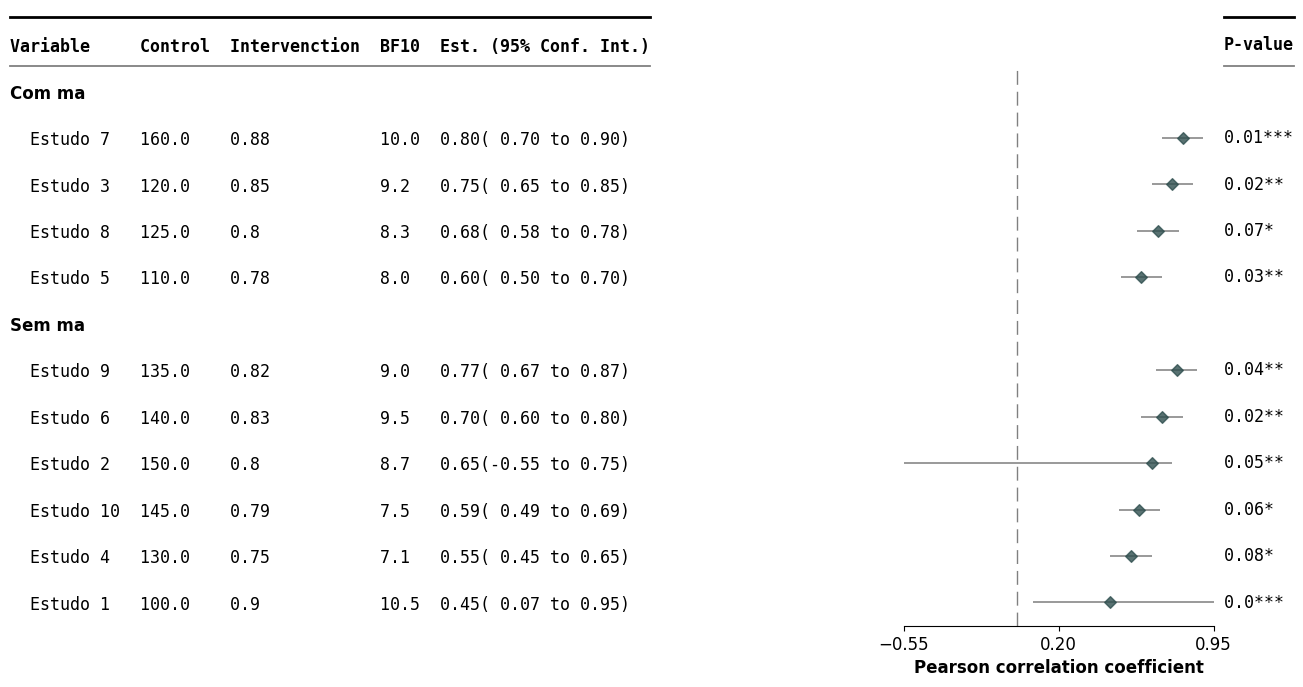

In [ ]:


# Plotando o Forest Plot
fp.forestplot(df,  # the dataframe with results data
              estimate="r",  # col containing estimated effect size
              ll="ll", hl="hl",  # lower & higher limits of conf. int.
              varlabel="label",  # column containing the varlabels to be printed on far left
              capitalize="capitalize",  # Capitalize labels
              pval="p-val",  # column containing p-values to be formatted
              annote=["control", "Intervenction", "BF10","est_ci"],  # columns to report on left of plot
              annoteheaders=["Control", "Intervenction", "BF10","Est. (95% Conf. Int.)"],  # ^corresponding headers
              rightannote=["formatted_pval"],  # columns to report on right of plot
              right_annoteheaders=["P-value"],  # ^corresponding headers
              groupvar="group",  # column containing group labels
              group_order=set(df['group'].tolist()),  # Se os grupos forem nomeados
              xlabel="Pearson correlation coefficient",  # x-label title
              xticks=[min_value,(min_value+max_value)/2, max_value],  # x-ticks to be printed
              sort=True,  # sort estimates in ascending order
              table=True,  # Format as a table
              # Additional kwargs for customizations
              **{"marker": "D",  # set maker symbol as diamond
                 "markersize": 35,  # adjust marker size
                 "xlinestyle": (0, (10, 5)),  # long dash for x-reference line
                 "xlinecolor": "#808080",  # gray color for x-reference line
                 "xtick_size": 12,  # adjust x-ticker fontsize
                }
              )

plt.show()


# Funel Plot

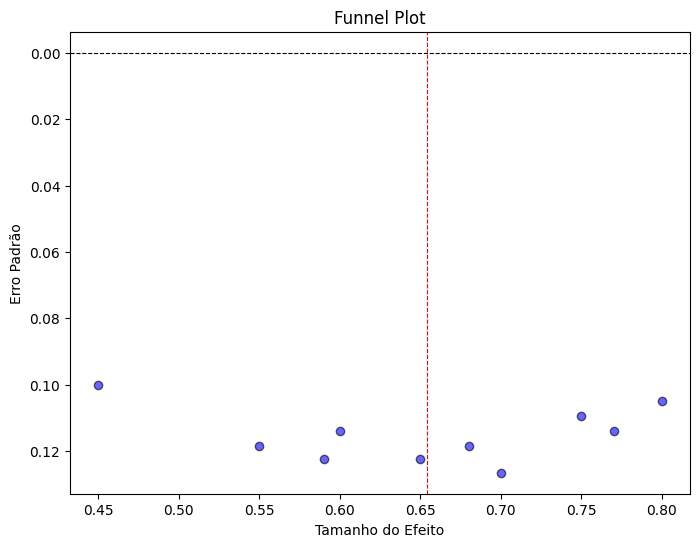

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Criando os dados a partir do DataFrame já existente
# Exemplo: variância e tamanho do efeito
effect_size = df['r']  # Tamanho do efeito
variance = df['var']  # Variância associada

# Calculando o erro padrão (sqrt da variância)
std_error = np.sqrt(variance)

# Criando o Funnel Plot
plt.figure(figsize=(8, 6))
plt.scatter(effect_size, std_error, c='b', alpha=0.6, edgecolors='k')  # Dispersão dos pontos

# Adicionando as linhas de referência
plt.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
plt.axvline(x=np.mean(effect_size), color='red', linewidth=0.8, linestyle='--')

# Invertendo o eixo Y para que erros menores fiquem no topo
plt.gca().invert_yaxis()

# Configurações do gráfico
plt.title('Funnel Plot')
plt.xlabel('Tamanho do Efeito')
plt.ylabel('Erro Padrão')

# Exibindo o gráfico
plt.show()


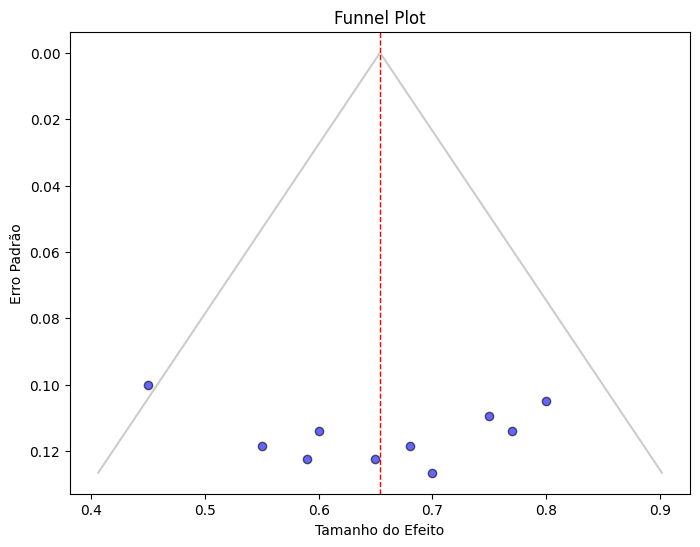

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Dados simulados: Tamanho do efeito e variância
effect_size = df['r']  # Tamanho do efeito
variance = df['var']  # Variância
std_error = np.sqrt(variance)  # Erro padrão

# Calculando a média do tamanho do efeito
mean_effect = np.mean(effect_size)

# Configurações do gráfico
plt.figure(figsize=(8, 6))

# Plotando os pontos dos estudos
plt.scatter(effect_size, std_error, c='b', alpha=0.6, edgecolors='k')

# Definindo a altura máxima (erro padrão máximo)
max_se = max(std_error)

# Definindo os limites do funil (IC 95%)
x_left = mean_effect - 1.96 * max_se
x_right = mean_effect + 1.96 * max_se

# Desenhando o triângulo do funil
plt.plot([x_left, mean_effect, x_right], [max_se, 0, max_se], color='gray', alpha=0.4)

# Adicionando a linha de referência da média do tamanho do efeito
plt.axvline(mean_effect, color='red', linestyle='--', linewidth=1)

# Invertendo o eixo Y para que erros menores fiquem no topo
plt.gca().invert_yaxis()

# Configurações finais do gráfico
plt.title('Funnel Plot')
plt.xlabel('Tamanho do Efeito')
plt.ylabel('Erro Padrão')

# Exibindo o gráfico
plt.show()
